First lab: up to step 3

# Step 1

In [13]:
import pandas as pd
df = pd.read_csv("Dataset1.csv")
print("(observations, variables) = ", df.shape)

missing = df.isna().sum()
print("Missing values in each column:\n", missing)

class_balance = df["Purchased"].value_counts()
print("Class balance:\n", class_balance)

(observations, variables) =  (400, 5)
Missing values in each column:
 User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64
Class balance:
 Purchased
0    257
1    143
Name: count, dtype: int64


Questions:
- 400 observations, 5 variables (user id, gender, age, estimated salary, purchased)
- The target has for Purchased, 257 in class 0 and 143 in class 1. This is not balanced. 
- No missing values in any column

In [14]:
predictors = df.drop(columns=["Purchased", "Gender"])
target = df["Purchased"]

# Step 2

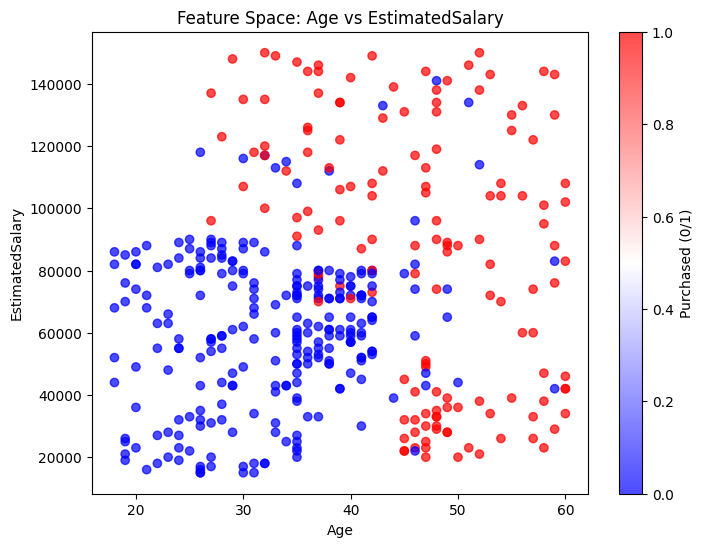

In [15]:
import matplotlib.pyplot as plt
x = predictors["Age"]
y = predictors["EstimatedSalary"]
labels = target

plt.figure(figsize=(8, 6))
scatter = plt.scatter(x, y, c=labels, cmap="bwr", alpha=0.7)
plt.xlabel("Age")
plt.ylabel("EstimatedSalary")
plt.title("Feature Space: Age vs EstimatedSalary")
plt.colorbar(scatter, label="Purchased (0/1)")
plt.show()

# Step 3

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(predictors, target, test_size=0.2, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("coefficients:", model.coef_, "intercept:", model.intercept_)


coefficients: [[-7.27967810e-07  2.08187177e-01  3.55216817e-05]] intercept: [-6.36710269e-06]


Questions:
- First coefficient is negative, second coefficient is positive
- Estimated slary increases the odds of purchase because it is positive

# Step 4

In [17]:
model.predict(X_test)
model.predict_proba(X_test)
accuracy_score_default_threshold = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy_score_default_threshold)

Accuracy: 0.8875


In [18]:
confusion_matrix(y_test, y_pred)

array([[50,  2],
       [ 7, 21]])

Questions:
- ???
- The modelp reidcts 88.75 % of purchased classes correctly for each person. 
- No accuracy is not sufficient becayse ????

# Step 5: Effect of the Classification Threshold

In [19]:
threshold = 0.3
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= threshold).astype(int)
accuracy_score_threshold_3= accuracy_score(y_test, y_pred)
print("Accuracy with threshold 0.3:", accuracy_score_threshold_3)

Accuracy with threshold 0.3: 0.8875


In [20]:
confusion_matrix(y_test, y_pred)

array([[46,  6],
       [ 3, 25]])

In [21]:
threshold = 0.7
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= threshold).astype(int)
accuracy_score_threshold_7 = accuracy_score(y_test, y_pred)
print("Accuracy with threshold 0.7:", accuracy_score_threshold_7)


Accuracy with threshold 0.7: 0.8125


In [22]:
confusion_matrix(y_test, y_pred)

array([[51,  1],
       [14, 14]])

# Step 6

# Step 7

# Step 8

# Step 9